In [16]:
import sys; print(sys.path)
import matplotlib.pyplot as plt
import neurokit2 as nk
import mne
import pathlib
import matplotlib
import pandas as pd
import numpy as np


['C:\\Users\\Filip\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\Filip\\AppData\\Local\\Programs\\Python\\Python311\\DLLs', 'C:\\Users\\Filip\\AppData\\Local\\Programs\\Python\\Python311\\Lib', 'C:\\Users\\Filip\\AppData\\Local\\Programs\\Python\\Python311', 'c:\\Users\\Filip\\Documents\\ProjektRnovi\\newvenv', '', 'c:\\Users\\Filip\\Documents\\ProjektRnovi\\newvenv\\Lib\\site-packages', 'c:\\Users\\Filip\\Documents\\ProjektRnovi\\newvenv\\Lib\\site-packages\\win32', 'c:\\Users\\Filip\\Documents\\ProjektRnovi\\newvenv\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\Filip\\Documents\\ProjektRnovi\\newvenv\\Lib\\site-packages\\Pythonwin']


In [17]:
train_df = pd.read_csv('data/train.csv')
train_df.head()

,crew,experiment,time,seat,eeg_fp1,eeg_f7,eeg_f8,eeg_t4,eeg_t6,eeg_t5,...,eeg_c4,eeg_p4,eeg_poz,eeg_c3,eeg_cz,eeg_o2,ecg,r,gsr,event
0,1,CA,0.011719,1,-5.28545,26.775801,-9.527310,-12.793200,16.717800,33.737499,...,37.368999,17.437599,19.201900,20.5968,-3.95115,14.507600,-4520.0,817.705994,388.829987,A
1,1,CA,0.015625,1,-2.42842,28.430901,-9.323510,-3.757230,15.969300,30.443600,...,31.170799,19.399700,19.689501,21.3547,1.33212,17.750200,-4520.0,817.705994,388.829987,A
2,1,CA,0.019531,1,10.67150,30.420200,15.350700,24.724001,16.143101,32.142799,...,-12.012600,19.396299,23.171700,22.4076,1.53786,22.247000,-4520.0,817.705994,388.829987,A
3,1,CA,0.023438,1,11.45250,25.609800,2.433080,12.412500,20.533300,31.494101,...,18.574100,23.156401,22.641199,19.3367,2.54492,18.998600,-4520.0,817.705994,388.829987,A
4,1,CA,0.027344,1,7.28321,25.942600,0.113564,5.748000,19.833599,28.753599,...,6.555440,22.754700,22.670300,20.2932,1.69962,22.812799,-4520.0,817.705994,388.829987,A


In [29]:
from mne import create_info
from mne.io import RawArray


eeg_f3_data = train_df['eeg_f3'].values
eeg_f4_data = train_df['eeg_f4'].values
eeg_pz_data = train_df['eeg_pz'].values
eeg_cz_data = train_df['eeg_cz'].values
eeg_p3_data = train_df['eeg_p3'].values
eeg_p4_data = train_df['eeg_p4'].values


data = np.vstack([eeg_f3_data, eeg_f4_data, eeg_pz_data, eeg_cz_data, eeg_p3_data,eeg_p4_data])


sfreq = 256
ch_names = ['F3', 'F4', 'Pz', 'Cz','P3','P4']
ch_types = ['eeg'] * len(ch_names)
info = create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = RawArray(data, info)
print(raw)


Creating RawArray with float64 data, n_channels=6, n_times=4867421
    Range : 0 ... 4867420 =      0.000 ... 19013.359 secs
Ready.
<RawArray | 6 x 4867421 (19013.4 s), ~222.8 MB, data loaded>


In [30]:
print(eeg_f3_data)

[ 18.447001  20.510599  23.162901 ... -20.4505   -44.365299   2.73318 ]


In [31]:
print(eeg_f3_data.shape)

(4867421,)


In [32]:
print(raw)


<RawArray | 6 x 4867421 (19013.4 s), ~222.8 MB, data loaded>


Using matplotlib as 2D backend.


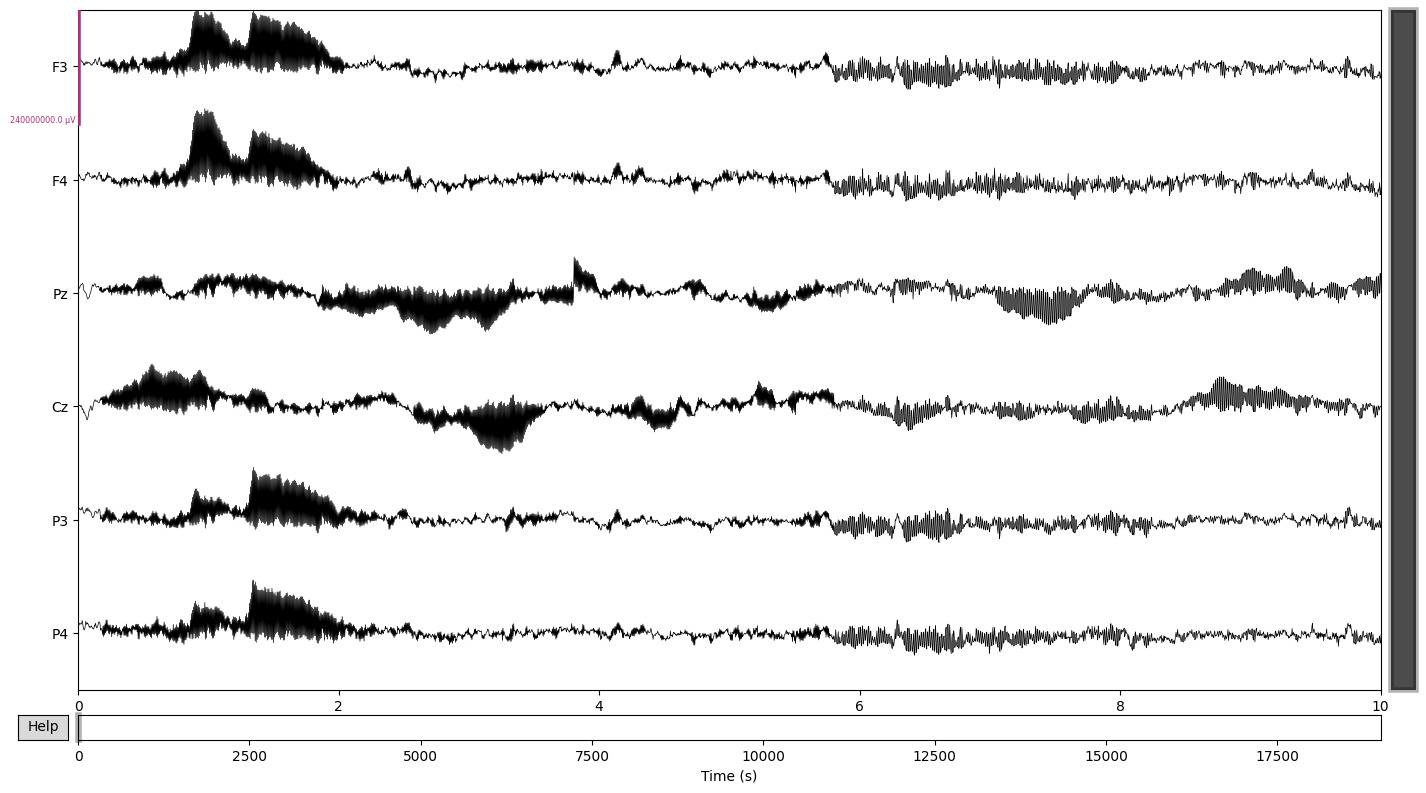

In [33]:
scalings = {'eeg': 120}
raw.plot(scalings=scalings, block=True);  



Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)

Fitting ICA to data using 6 channels (please be patient, this may take a while)
Selecting by number: 6 components
Fitting ICA took 23.7s.


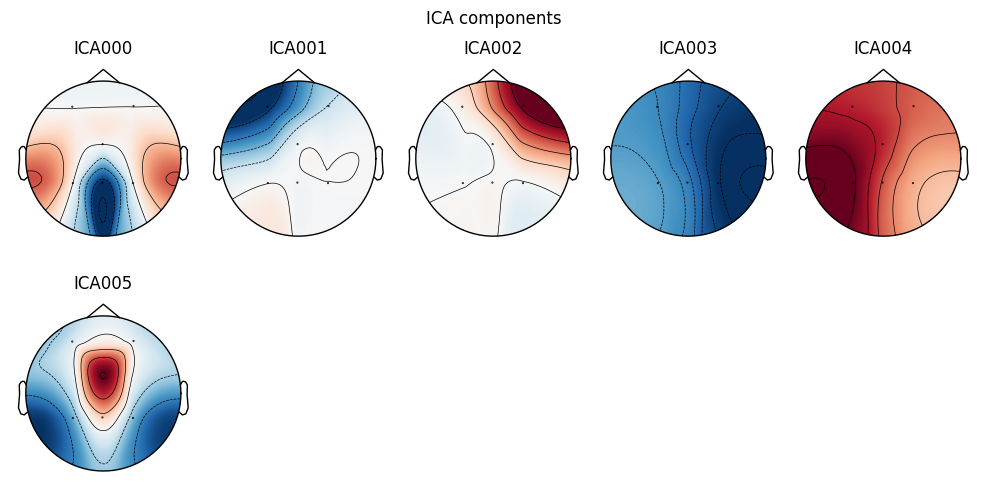

Applying ICA to Raw instance
    Transforming to ICA space (6 components)
    Zeroing out 2 ICA components
    Projecting back using 6 PCA components


In [35]:
from mne.preprocessing import ICA

raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=40.0)

montage = mne.channels.make_standard_montage("standard_1020")
raw_filtered.set_montage(montage)


ica = ICA(n_components=6, random_state=42, max_iter=800)

ica.fit(raw_filtered)

ica.plot_components()

ica.exclude = [0, 1]  
raw_cleaned = ica.apply(raw_filtered)

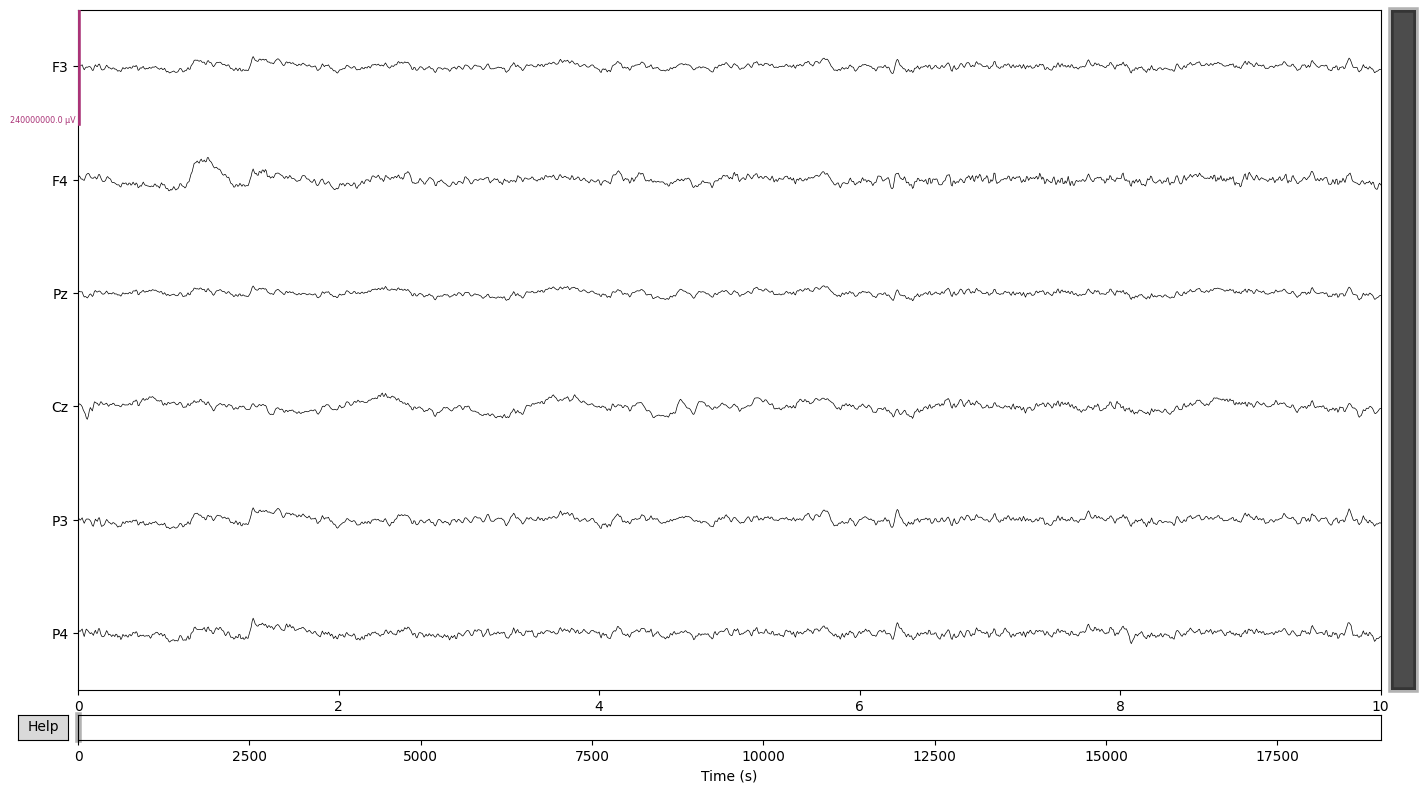

In [13]:
scalings = {'eeg': 120}
raw_cleaned.plot(scalings=scalings, block=True);  

In [ ]:
# Save the preprocessed data to a .fif file
raw_cleaned.save("eeg_preprocessed_raw.fif", overwrite=True)


In [8]:
from scipy.stats import skew, kurtosis, entropy
from scipy.signal import welch
from scipy.integrate import simpson
import pywt  
from mne import io

# Load the saved file
raw_loaded = io.read_raw_fif('eeg_preprocessed_raw.fif', preload=True)
eeg_data = raw_loaded.get_data()  

window_size = 5  # 5 seconds
step_size = 1    # Updated every second
fs = raw_loaded.info['sfreq']  # Sampling frequency
window_samples = int(window_size * fs)
step_samples = int(step_size * fs)
n_channels, n_samples = eeg_data.shape


windows = []
for start in range(0, n_samples - window_samples + 1, step_samples):
    end = start + window_samples
    windows.append(eeg_data[:, start:end])
    

Opening raw data file eeg_preprocessed_raw.fif...
    Range : 0 ... 4867420 =      0.000 ... 19013.359 secs
Ready.
Reading 0 ... 4867420  =      0.000 ... 19013.359 secs...


In [9]:
def extract_summary_statistics(signal):
    mean = np.mean(signal)
    variance = np.var(signal)
    skewness = skew(signal)
    kurt = kurtosis(signal)
    cv = np.std(signal) / mean if mean != 0 else 0
    quantiles = np.percentile(signal, [0.5, 2.5, 25, 50, 75, 97.5, 99.5])
    iqr = quantiles[4] - quantiles[2]
    pdf, _ = np.histogram(signal, bins=50, density=True)
    signal_entropy = entropy(pdf)
    auc = simpson(signal)
    return [mean, variance, skewness, kurt, cv, *quantiles, iqr, signal_entropy, auc]


In [10]:
def extract_psd(signal, fs, fmin=1, fmax=40):

    freqs, psd = welch(signal, fs, nperseg=fs*2)  
    

    freq_resolution = freqs[1] - freqs[0] 
    desired_freqs = np.arange(fmin, fmax + 1, freq_resolution)
    psd_dict = dict(zip(freqs, psd))
    

    psd_1hz_bins = []
    for f in range(fmin, fmax + 1):
        closest_freq = min(psd_dict.keys(), key=lambda x: abs(x - f))
        psd_1hz_bins.append(psd_dict[closest_freq])
    
    return psd_1hz_bins



In [11]:

def extract_wavelet_features(signal, wavelet='db4', level=7, window_size=256, window_increment=32):
    features = []
    num_samples = len(signal)
    
    for start in range(0, num_samples - window_size + 1, window_increment):
        window = signal[start:start + window_size]
        coeffs = pywt.wavedec(window, wavelet, level=level)
        flattened_coeffs = np.hstack(coeffs)
        features.append(flattened_coeffs)

    return np.array(features)


In [18]:
features_list = []
for window in windows:
    window_features = []
    for ch_idx in range(n_channels):
        channel_data = window[ch_idx]
        
        # Summary statistics
        summary_stats = extract_summary_statistics(channel_data)  # List of 15 features
        
        # PSD
        psd_features = extract_psd(channel_data, fs)  # List of 40 features
        
        # Wavelet decomposition
        
        # Store features for this channel as separate lists
        channel_features = [summary_stats, psd_features]
        window_features.append(channel_features)  # Append to window features
    
    features_list.append(window_features)  # Append all channel features for this window



In [22]:
print(features_list[0][0][0])

[np.float64(-0.4242324832231589), np.float64(40.49933837962216), np.float64(0.35516005313487975), np.float64(-0.25886417835973896), np.float64(-15.00099426689311), np.float64(-13.397458543777466), np.float64(-11.637305808067321), np.float64(-4.971166491508484), np.float64(-1.0561022758483887), np.float64(3.6540358662605286), np.float64(13.009189105033872), np.float64(15.891131954193117), np.float64(8.625202357769012), np.float64(3.576655041925721), np.float64(-543.3461180646553)]


In [26]:
import csv

def flatten_and_convert(nested_list):
    flattened = []
    for item in nested_list:
        if isinstance(item, list):  # Check if the item is a list
            flattened.extend(flatten_and_convert(item))
        else:  # Convert np.float64 to regular float
            flattened.append(float(item))
    return flattened

# Process features_list
processed_features_list = [flatten_and_convert(row) for row in features_list]

base_features = [
    "mean", "variance", "skewness", "kurtosis", "cv", "q005", "q025", 
    "q25", "q50", "q75", "q975", "q995", "iqr", "entropy", "auc"
]
psd_count = 40
channels = ["F3", "F4", "Pz", "Cz", "P3", "P4"]

column_names = []

# Add base features for each channel
for channel in channels:
    column_names.extend([f"{channel}_{feature}" for feature in base_features])

# Add PSD features for each channel
for channel in channels:
    column_names.extend([f"{channel}_PSD{i}" for i in range(1, psd_count + 1)])

# Save processed_features_list to a CSV file
csv_filename = "features_list_with_headers.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    
    # Write the header row
    writer.writerow(column_names)
    
    # Write the data rows
    writer.writerows(processed_features_list)

print(f"Data saved to {csv_filename}")

Data saved to features_list_with_headers.csv


In [15]:
window_idx = 7
channel_idx = 1

summary_stats = features_list[window_idx][channel_idx][0]
psd_features = features_list[window_idx][channel_idx][1]


print("Summary Stats:", summary_stats)
print("PSD Features:", psd_features)



Summary Stats: [np.float64(0.4867138173522676), np.float64(81.23044882356592), np.float64(0.4592184134578977), np.float64(0.8997719698565825), np.float64(18.517644862232242), np.float64(-20.91814031600952), np.float64(-16.556822729110717), np.float64(-4.976994872093201), np.float64(-0.1085035391151905), np.float64(5.312543988227844), np.float64(21.920553922653177), np.float64(30.486537313461312), np.float64(10.289538860321045), np.float64(3.4207684594711605), np.float64(627.123689962648)]
PSD Features: [np.float64(11.410488705319437), np.float64(15.365655716153316), np.float64(1.3196215372134945), np.float64(4.209921401157571), np.float64(1.2824305167023677), np.float64(2.2044240847030037), np.float64(1.5578868208170402), np.float64(1.1221000962034353), np.float64(1.1759887239986735), np.float64(1.4990682004851623), np.float64(1.1592920145129342), np.float64(1.5894761418353647), np.float64(0.944410016424904), np.float64(0.4688113805273397), np.float64(0.40310088290756835), np.float64(0

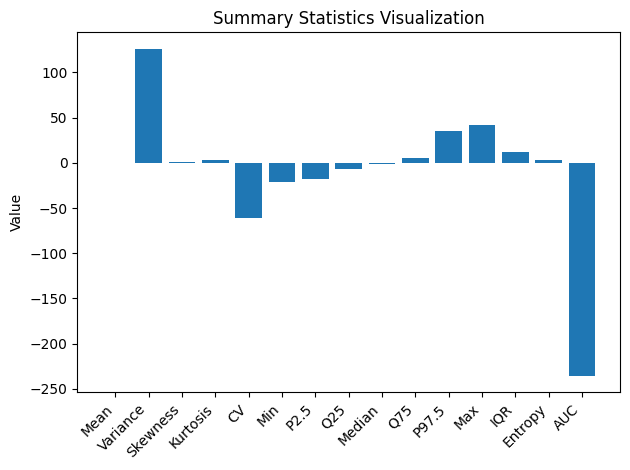

In [17]:
import matplotlib.pyplot as plt


summary_stats = features_list[0][1][0]  # Example window 0, channel 1, summary stats
stats_labels = ['Mean', 'Variance', 'Skewness', 'Kurtosis', 'CV', 'Min', 'P2.5', 'Q25', 
                'Median', 'Q75', 'P97.5', 'Max', 'IQR', 'Entropy', 'AUC']

plt.bar(stats_labels, summary_stats)
plt.xticks(rotation=45, ha='right')
plt.title('Summary Statistics Visualization')
plt.ylabel('Value')
plt.tight_layout()
plt.show()


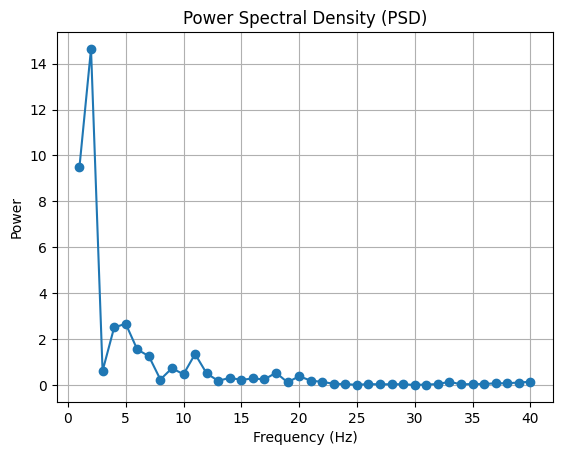

In [18]:
# Example: Visualize PSD for one channel in one window
psd_features = features_list[0][0][1]  # Example window 0, channel 0, PSD features
freqs = list(range(1, len(psd_features) + 1))  # 1 Hz to 40 Hz bins

plt.plot(freqs, psd_features, marker='o')
plt.title('Power Spectral Density (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.grid(True)
plt.show()


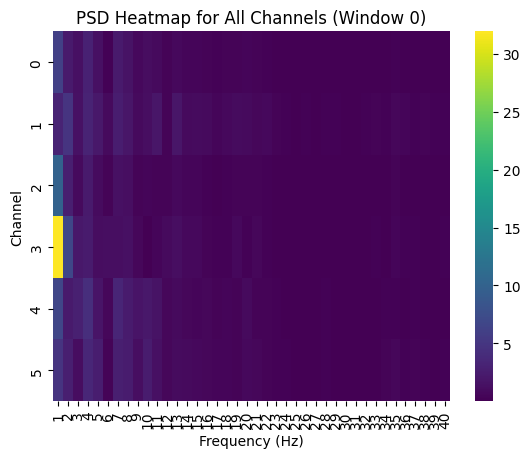

In [19]:
import numpy as np
import seaborn as sns


psd_all_channels = [features_list[5][ch][1] for ch in range(len(features_list[0]))] 
sns.heatmap(np.array(psd_all_channels), cmap='viridis', xticklabels=freqs)
plt.title('PSD Heatmap for All Channels (Window 0)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Channel')
plt.show()

## Merging the eeg features with the combined ECG,respiratory and GSR features
    Both files contain summary statistics of 5 second windows, additionally EEG data contains Power Spectral Density(PSD) of different frequency ranges from 1 up to 40Hz.
    

In [37]:
import pandas as pd

your_file = "features_list_with_headers.csv"  
features_file = "features.csv"
output_file = "merged_features_second_last.csv"

your_df = pd.read_csv(your_file)
features_df = pd.read_csv(features_file)


if len(your_df) != len(features_df):
    raise ValueError(f"Row mismatch: your file has {len(your_df)} rows, but features.csv has {len(features_df)} rows.")


insert_position = len(features_df.columns) - 1

# Split the features DataFrame into two parts
left_part = features_df.iloc[:, :insert_position]
right_part = features_df.iloc[:, insert_position:]

# Concatenate the DataFrames
merged_df = pd.concat([left_part, your_df, right_part], axis=1)


merged_df.rename(columns={merged_df.columns[-1]: "event"}, inplace=True)

# Save the result 
merged_df.to_csv(output_file, index=False)

print(f"Files merged successfully. Output saved to {output_file}.")

Files merged successfully. Output saved to merged_features_second_last.csv.
